## Датасет: Rain in Australia (прогноз дождя на завтра)

**Целевая переменная:** RainTomorrow - будет ли дождь завтра.

---

## Гипотезы

1. Логистическая регрессия с L2-регуляризацией (Ridge) покажет более высокий ROC-AUC, чем модель без регуляризации, благодаря снижению влияния мультиколлинеарности.

2. Дерево решений начнет переобучаться при глубине (max_depth) больше 8: качество на обучении будет расти, а на тесте — падать.

3. Признак Rainfall (количество осадков сегодня) будет самым важным для предсказания дождя завтра.

4. Удаление сильно коррелированных признаков улучшит качество логистической регрессии, но не повлияет на деревья.

5. Из-за дисбаланса классов accuracy будет завышена, а F1-score для класса «дождь» - низким. Применение class_weight='balanced' должно повысить F1 для меньшего класса.

6. Градиентный бустинг (XGBoost) покажет лучший ROC-AUC по сравнению с логистической регрессией и случайным лесом, так как лучше выявляет нелинейные зависимости.

7. Стандартизация признаков (StandardScaler) улучшит сходимость и качество логистической регрессии, но не повлияет на деревья.

# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

print("Все библиотеки загружены")

Все библиотеки загружены


#Загрузка и первичный EDA


In [2]:
df = pd.read_csv('weatherAUS.csv')

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер датасета: 145460 строк, 23 столбцов


In [3]:
display(df.head())

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [5]:
display(df.describe())

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


Анализ пропущенных значений

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Пропуски по столбцам:")
display(missing)

Пропуски по столбцам:


,0
Sunshine,69835
Evaporation,62790
Cloud3pm,59358
Cloud9am,55888
Pressure9am,15065
Pressure3pm,15028
WindDir9am,10566
WindGustDir,10326
WindGustSpeed,10263
Humidity3pm,4507


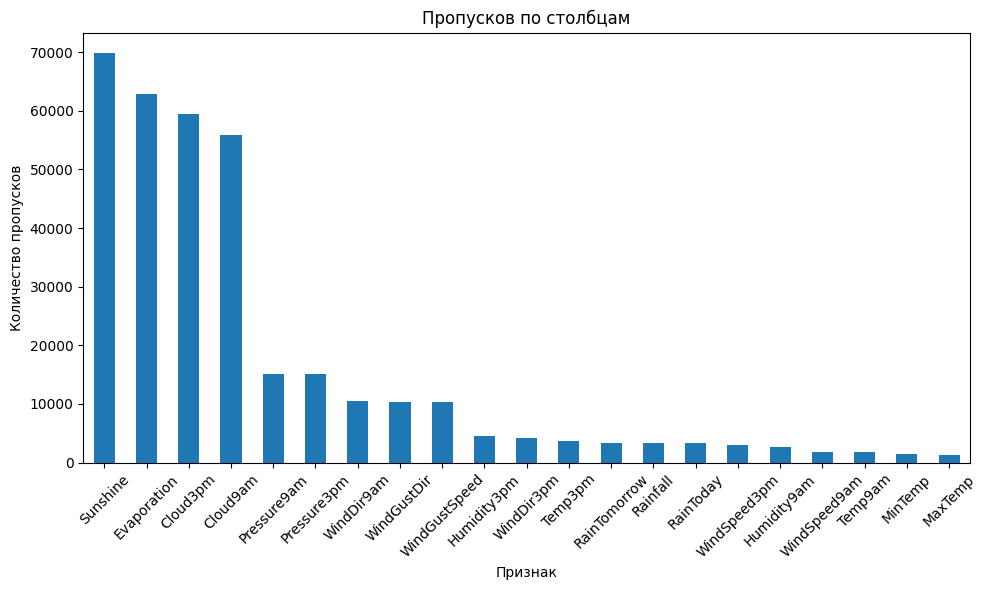

In [7]:
plt.figure(figsize=(10, 6))
missing.plot(kind='bar')
plt.title('Пропусков по столбцам')
plt.xlabel('Признак')
plt.ylabel('Количество пропусков')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Анализ целевой переменной

In [8]:
df_clean = df.dropna(subset=['RainTomorrow'])
print(f"После удаления пропусков в целевой переменной: {df_clean.shape[0]} строк")

После удаления пропусков в целевой переменной: 142193 строк



Распределение целевой переменной:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

В процентах:
RainTomorrow
No     77.58
Yes    22.42
Name: proportion, dtype: float64


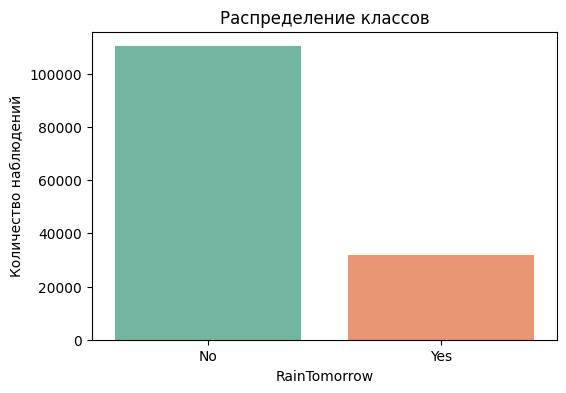

In [9]:
target_counts = df_clean['RainTomorrow'].value_counts()
target_percent = df_clean['RainTomorrow'].value_counts(normalize=True) * 100

print("\nРаспределение целевой переменной:")
print(target_counts)
print(f"\nВ процентах:\n{target_percent.round(2)}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='RainTomorrow', palette='Set2')
plt.title('Распределение классов')
plt.ylabel('Количество наблюдений')
plt.show()

Анализ числовых признаков

In [10]:
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(f"Числовые признаки: {num_cols}")

Числовые признаки: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


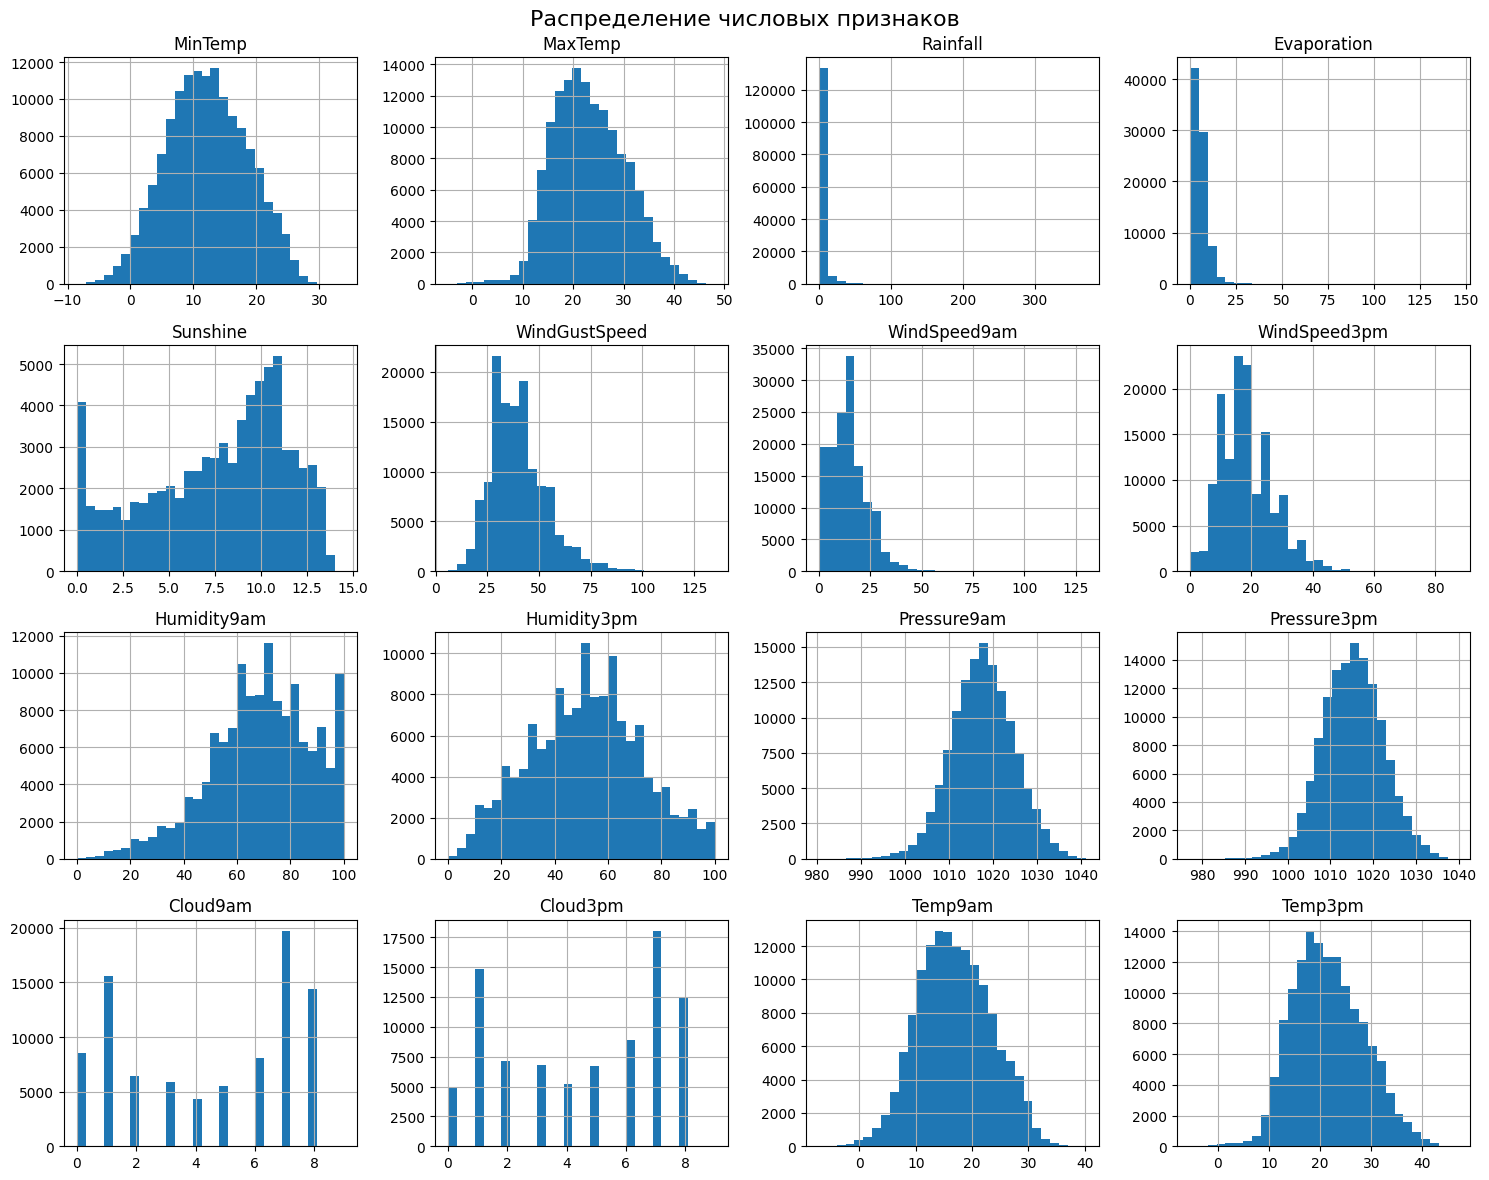

In [11]:
df_clean[num_cols].hist(bins=30, figsize=(15, 12))
plt.suptitle('Распределение числовых признаков', size=16)
plt.tight_layout()
plt.show()

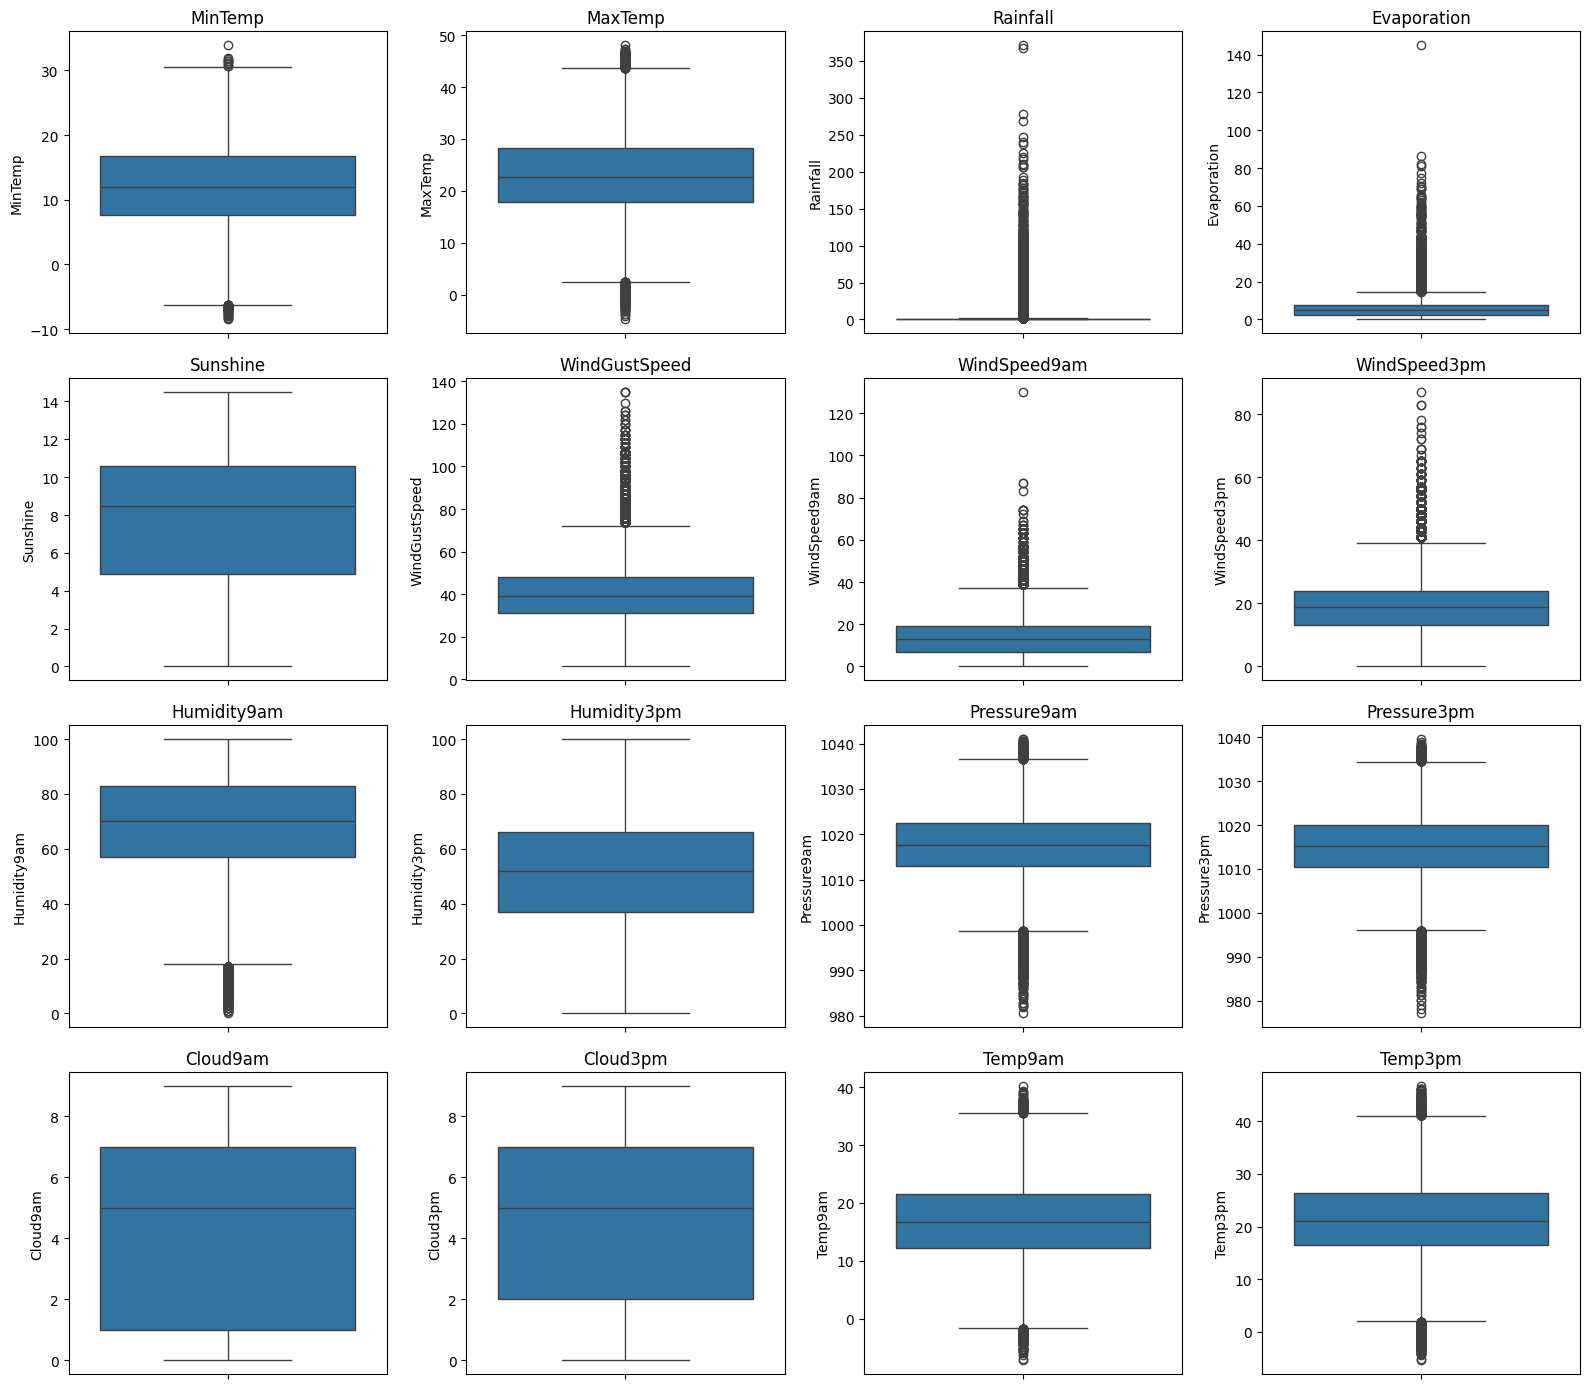

In [12]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols[:16]):
    sns.boxplot(data=df_clean, y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

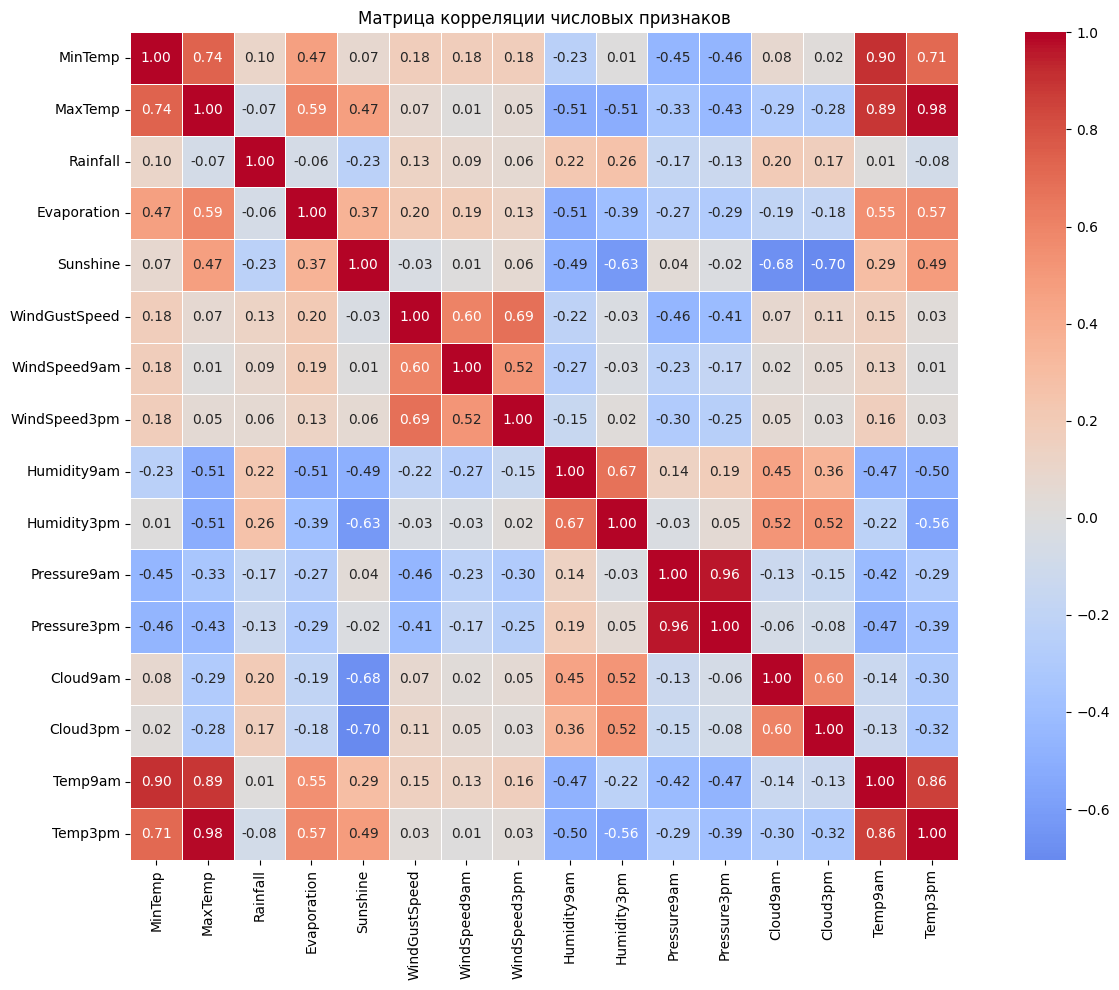

In [13]:
plt.figure(figsize=(14, 10))
corr_matrix = df_clean[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Матрица корреляции числовых признаков')
plt.tight_layout()
plt.show()

In [14]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(column, upper[column].idxmax(), upper[column].max())
             for column in upper.columns if any(upper[column] > 0.8)]

print("\nСильно коррелированные пары признаков:")
for pair in high_corr:
    print(f"  {pair[0]} ↔ {pair[1]}: {pair[2]:.2f}")


Сильно коррелированные пары признаков:
  Pressure3pm ↔ Pressure9am: 0.96
  Temp9am ↔ MinTemp: 0.90
  Temp3pm ↔ MaxTemp: 0.98


Анализ категориальных признаков

In [15]:
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('RainTomorrow')

print(f"Категориальные признаки: {cat_cols}")

for col in cat_cols:
    print(f"\n{col}:")
    display(df_clean[col].value_counts().head(10))

Категориальные признаки: ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

Date:


,count
Date,
2017-06-23,49
2013-03-04,49
2014-04-13,49
2014-03-25,49
2017-05-18,49
2017-06-15,49
2017-06-14,49
2017-06-12,49
2017-06-10,49



Location:


,count
Location,
Canberra,3418
Sydney,3337
Perth,3193
Darwin,3192
Hobart,3188
Brisbane,3161
Adelaide,3090
Bendigo,3034
Townsville,3033



WindGustDir:


...

,count
WindDir9am,
N,11393
SE,9162
E,9024
SSE,8966
NW,8552
S,8493
W,8260
SW,8237
NNE,7948



WindDir3pm:


,count
WindDir3pm,
SE,10663
W,9911
S,9598
WSW,9329
SW,9182
SSE,9142
N,8667
WNW,8656
NW,8468



RainToday:


,count
RainToday,
No,109332
Yes,31455


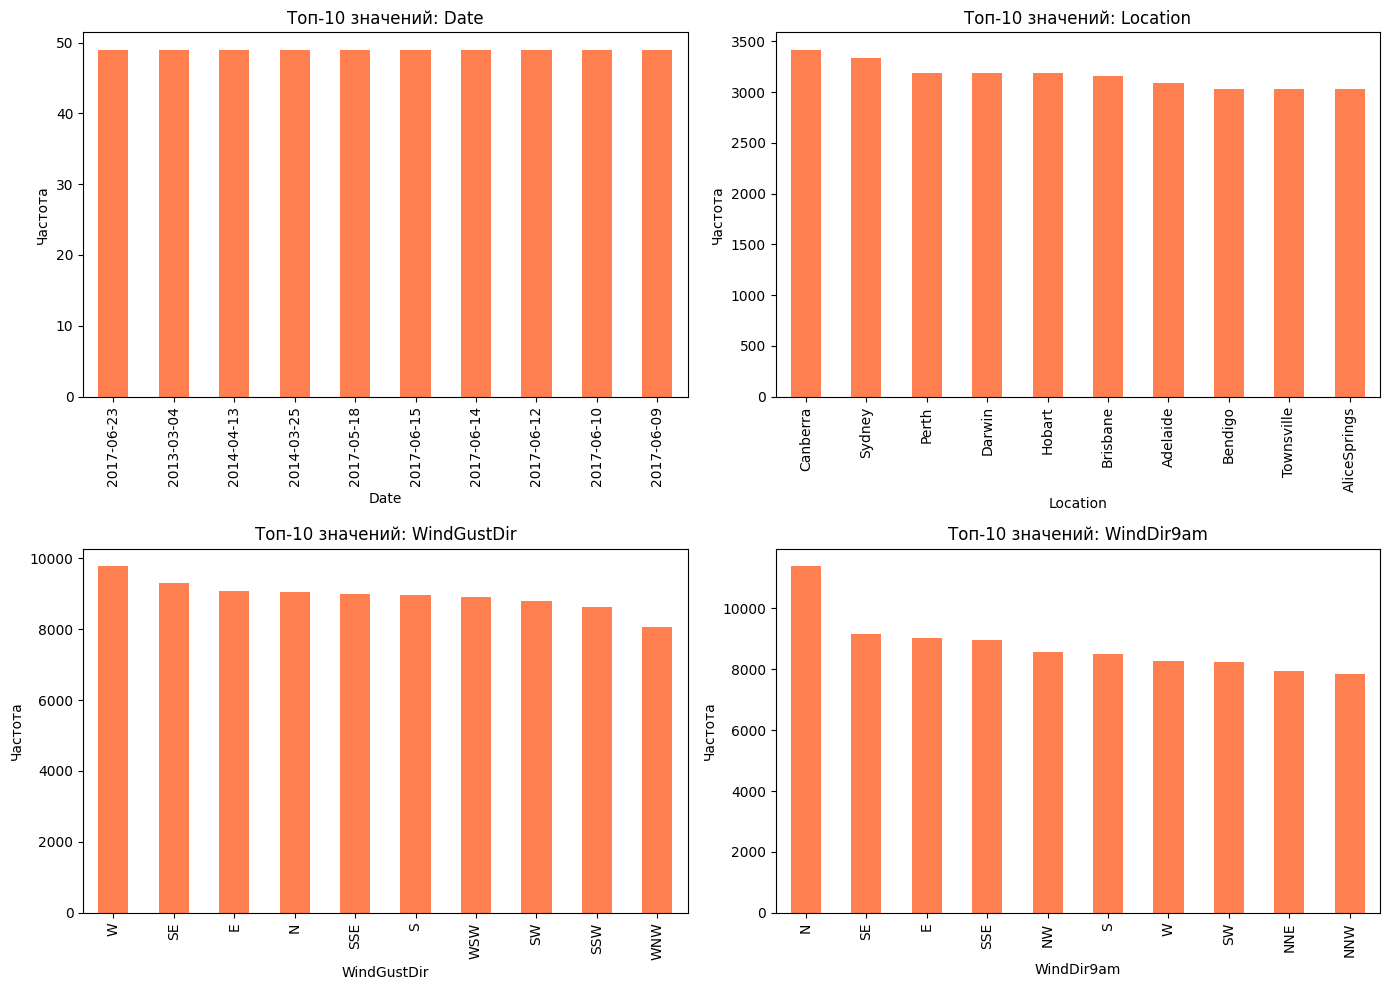

In [16]:

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:4]):
    df_clean[col].value_counts().head(10).plot(kind='bar', ax=axes[i], color='coral')
    axes[i].set_title(f'Топ-10 значений: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
plt.tight_layout()
plt.show()

#Предобработка

In [17]:
y = df_clean['RainTomorrow'].map({'Yes': 1, 'No': 0})

X = df_clean.drop(columns=['RainTomorrow'])

print(f"X: {X.shape[0]} строк, {X.shape[1]} признаков")
print(f"y: {y.shape[0]} строк")
print(f"Распределение y:\n{y.value_counts()}")

X: 142193 строк, 22 признаков
y: 142193 строк
Распределение y:
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")
print(f"\nРаспределение y_train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nРаспределение y_test:\n{y_test.value_counts(normalize=True).round(3)}")

Обучающая выборка: 99535 строк
Тестовая выборка: 42658 строк

Распределение y_train:
RainTomorrow
0    0.776
1    0.224
Name: proportion, dtype: float64

Распределение y_test:
RainTomorrow
0    0.776
1    0.224
Name: proportion, dtype: float64


Пайплайн предобработки

Для числовых признаков:
1. Заполняем пропуски медианой
2. Масштабируем с помощью StandardScaler

Для категориальных признаков
1. Заполняем пропуски модой
2. One-hot encoding с drop='first' чтобы избежать мультиколлинеарности

In [19]:
num_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Числовых признаков: {len(num_features)}")
print(f"Категориальных признаков: {len(cat_features)}")

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

Числовых признаков: 16
Категориальных признаков: 6


In [20]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Размер X_train после предобработки: {X_train_processed.shape}")
print(f"Размер X_test после предобработки: {X_test_processed.shape}")

cat_onehot_names = []
for col in cat_features:
    unique_vals = X_train[col].dropna().unique()
    if len(unique_vals) > 1:
        cat_onehot_names.extend([f"{col}_{val}" for val in sorted(unique_vals)[1:]])
    else:
        cat_onehot_names.extend([f"{col}_{val}" for val in sorted(unique_vals)])

feature_names = num_features + cat_onehot_names
print(f"Всего признаков после предобработки: {len(feature_names)}")

Размер X_train после предобработки: (99535, 3504)
Размер X_test после предобработки: (42658, 3504)
Всего признаков после предобработки: 3504


Функция для оценки модели

In [21]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name='Model'):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

    print(f"\n{'='*50}")
    print(f"{model_name}")
    print('='*50)
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Предсказано')
    plt.ylabel('Истина')
    plt.show()

    return metrics, model

Базовые модели


Logistic Regression (C=1)
  Accuracy: 0.8547
  Precision: 0.7355
  Recall: 0.5496
  F1: 0.6291
  ROC-AUC: 0.8828


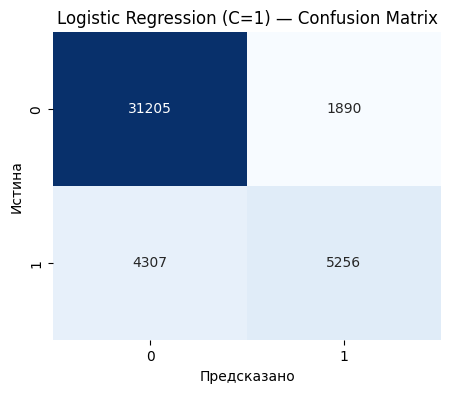


Decision Tree (max_depth=5)
  Accuracy: 0.8357
  Precision: 0.7723
  Recall: 0.3788
  F1: 0.5082
  ROC-AUC: 0.8320


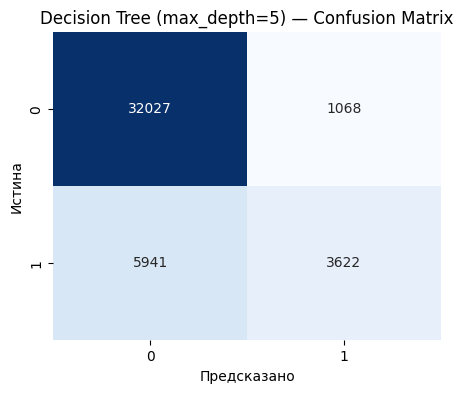


Random Forest (n_estimators=100)
  Accuracy: 0.8540
  Precision: 0.8068
  Recall: 0.4586
  F1: 0.5848
  ROC-AUC: 0.8896


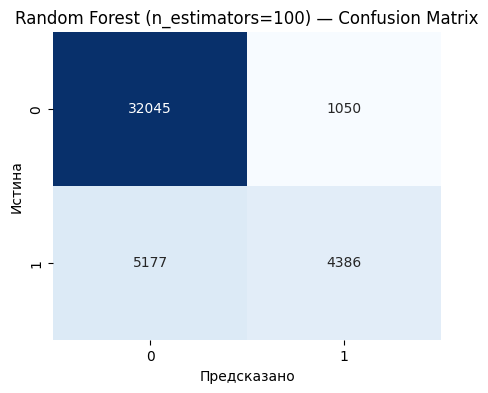

In [22]:
baseline_models = {
    'Logistic Regression (C=1)': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree (max_depth=5)': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest (n_estimators=100)': RandomForestClassifier(random_state=42, n_estimators=100)
}

baseline_results = {}
for name, model in baseline_models.items():
    metrics, fitted = evaluate_model(
        model, X_train_processed, y_train, X_test_processed, y_test, name
    )
    baseline_results[name] = metrics

Логистическая регрессия

Лучшие параметры LR: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший ROC-AUC (CV): 0.8814

Logistic Regression (tuned)
  Accuracy: 0.8548
  Precision: 0.7356
  Recall: 0.5498
  F1: 0.6293
  ROC-AUC: 0.8830


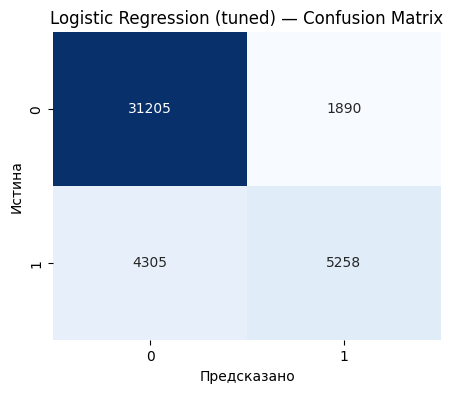

In [23]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

lr = LogisticRegression(random_state=42, max_iter=1000)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_processed, y_train)

print(f"Лучшие параметры LR: {grid_lr.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
lr_metrics, _ = evaluate_model(
    best_lr, X_train_processed, y_train, X_test_processed, y_test,
    'Logistic Regression (tuned)'
)

Дерево решений

Лучшие параметры DT: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Лучший ROC-AUC (CV): 0.8430

Decision Tree (tuned)
  Accuracy: 0.8399
  Precision: 0.7294
  Recall: 0.4541
  F1: 0.5598
  ROC-AUC: 0.8461


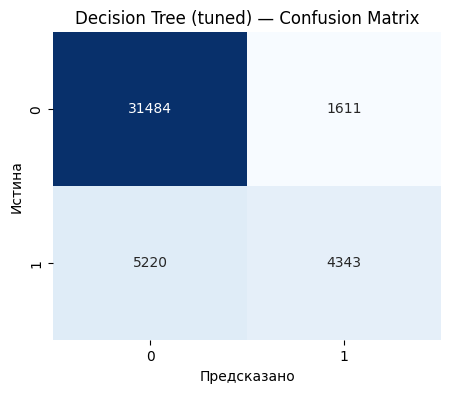

In [24]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train_processed, y_train)

print(f"Лучшие параметры DT: {grid_dt.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_dt.best_score_:.4f}")

best_dt = grid_dt.best_estimator_
dt_metrics, _ = evaluate_model(
    best_dt, X_train_processed, y_train, X_test_processed, y_test,
    'Decision Tree (tuned)'
)

Случайный лес

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Лучшие параметры RF: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Лучший ROC-AUC (CV): 0.8846

Random Forest (tuned, RandomizedSearch)
  Accuracy: 0.8552
  Precision: 0.8092
  Recall: 0.4631
  F1: 0.5891
  ROC-AUC: 0.8916


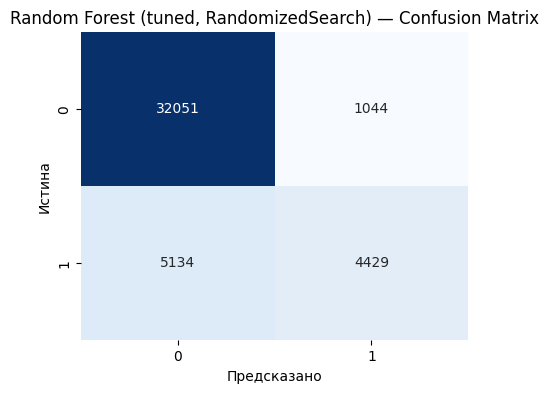

In [25]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_rf = RandomizedSearchCV(
    rf, param_dist_rf,
    n_iter=15,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_rf.fit(X_train_processed, y_train)

print(f"Лучшие параметры RF: {random_rf.best_params_}")
print(f"Лучший ROC-AUC (CV): {random_rf.best_score_:.4f}")

best_rf = random_rf.best_estimator_
rf_metrics, _ = evaluate_model(
    best_rf, X_train_processed, y_train, X_test_processed, y_test,
    'Random Forest (tuned, RandomizedSearch)'
)

XGBoost

Лучшие параметры XGB: {'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Лучший ROC-AUC (CV): 0.8919

XGBoost (tuned)
  Accuracy: 0.8617
  Precision: 0.7584
  Recall: 0.5620
  F1: 0.6456
  ROC-AUC: 0.8947


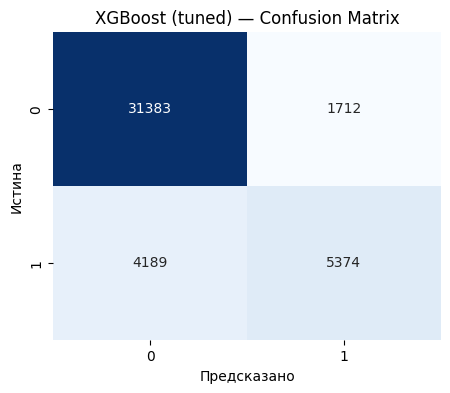

In [26]:
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train_processed, y_train)

print(f"Лучшие параметры XGB: {grid_xgb.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_
xgb_metrics, _ = evaluate_model(
    best_xgb, X_train_processed, y_train, X_test_processed, y_test,
    'XGBoost (tuned)'
)

Отбор признаков


Logistic Regression + SelectKBest (k=10)
  Accuracy: 0.8434
  Precision: 0.7230
  Recall: 0.4887
  F1: 0.5832
  ROC-AUC: 0.8620


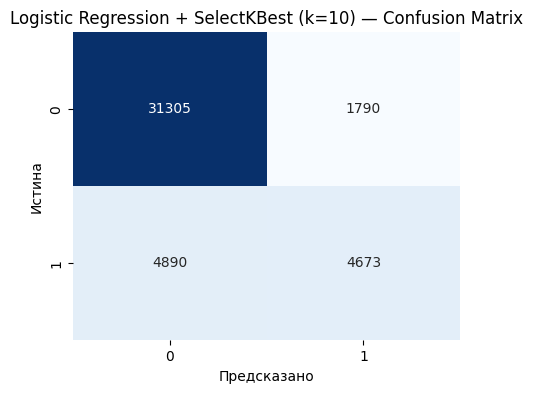


Топ-10 отобранных признаков:
  1. Rainfall
  2. Sunshine
  3. WindGustSpeed
  4. Humidity9am
  5. Humidity3pm
  6. Pressure9am
  7. Pressure3pm
  8. Cloud9am
  9. Cloud3pm
  10. RainToday_Yes


In [27]:
selector = SelectKBest(mutual_info_classif, k=10)
X_train_sel = selector.fit_transform(X_train_processed, y_train)
X_test_sel = selector.transform(X_test_processed)

lr_sel = LogisticRegression(**grid_lr.best_params_, random_state=42, max_iter=1000)
lr_sel_metrics, _ = evaluate_model(
    lr_sel, X_train_sel, y_train, X_test_sel, y_test,
    'Logistic Regression + SelectKBest (k=10)'
)

selected_indices = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_indices]
print("\nТоп-10 отобранных признаков:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

Проверяем гипотезу 4: удаленяем коррелированных признаки

Удаляем признаки: ['Pressure3pm', 'Temp9am', 'Temp3pm']
Их индексы: [11, 14, 15]
Новый размер X_train: (99535, 3501)

LR без коррелированных признаков (только 3 удалены)
  Accuracy: 0.8530
  Precision: 0.7330
  Recall: 0.5415
  F1: 0.6228
  ROC-AUC: 0.8802


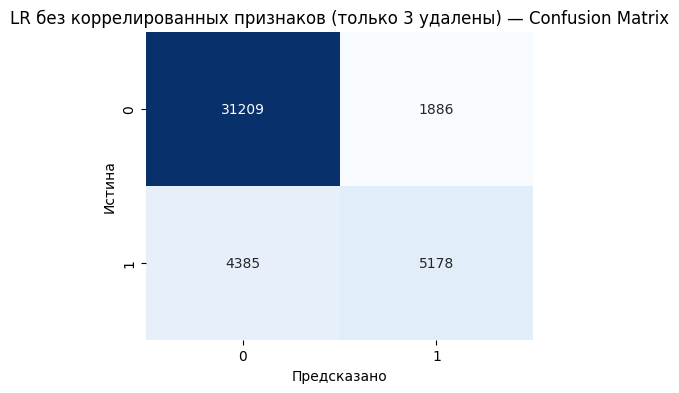

In [28]:
cat_onehot_names = []
for col in cat_features:
    unique_vals = X_train[col].dropna().unique()
    if len(unique_vals) > 1:
        cat_onehot_names.extend([f"{col}_{val}" for val in sorted(unique_vals)[1:]])
    else:
        cat_onehot_names.extend([f"{col}_{val}" for val in sorted(unique_vals)])

all_feature_names = num_features + cat_onehot_names

cols_to_drop_names = ['Pressure3pm', 'Temp9am', 'Temp3pm']

indices_to_drop = [i for i, name in enumerate(all_feature_names) if name in cols_to_drop_names]

print(f"Удаляем признаки: {cols_to_drop_names}")
print(f"Их индексы: {indices_to_drop}")

X_train_df = pd.DataFrame(X_train_processed.toarray())
X_test_df = pd.DataFrame(X_test_processed.toarray())

X_train_nocorr = X_train_df.drop(columns=indices_to_drop, axis=1).values
X_test_nocorr = X_test_df.drop(columns=indices_to_drop, axis=1).values

print(f"Новый размер X_train: {X_train_nocorr.shape}")

lr_nocorr = LogisticRegression(**grid_lr.best_params_, random_state=42, max_iter=1000)
lr_nocorr_metrics, _ = evaluate_model(
    lr_nocorr, X_train_nocorr, y_train, X_test_nocorr, y_test,
    'LR без коррелированных признаков'
)

Проверяем гипотезу 2: переобученаем дерево решений

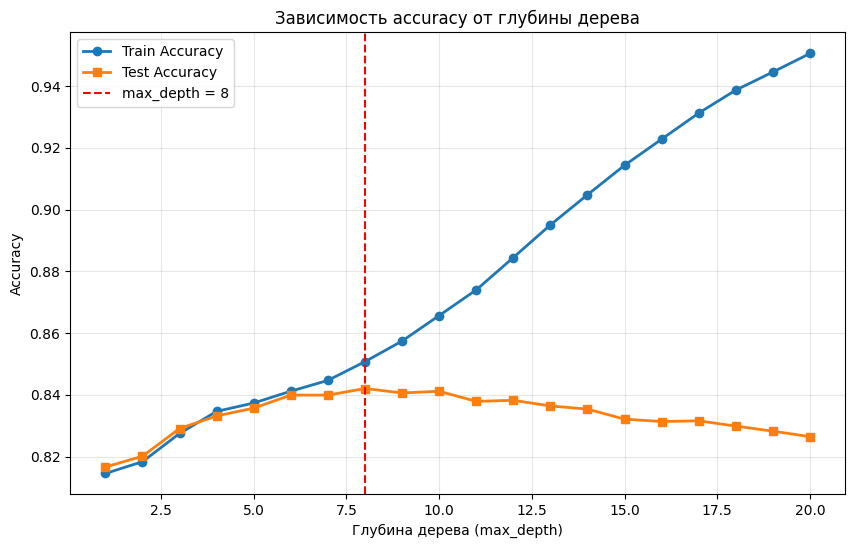

In [29]:
depths = range(1, 21)
train_acc = []
test_acc = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, min_samples_split=2,
                                min_samples_leaf=1, random_state=42)
    dt.fit(X_train_processed, y_train)
    train_acc.append(accuracy_score(y_train, dt.predict(X_train_processed)))
    test_acc.append(accuracy_score(y_test, dt.predict(X_test_processed)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_acc, 'o-', label='Train Accuracy', linewidth=2)
plt.plot(depths, test_acc, 's-', label='Test Accuracy', linewidth=2)
plt.axvline(x=8, color='red', linestyle='--', label='max_depth = 8')
plt.xlabel('Глубина дерева (max_depth)')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от глубины дерева')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Проверяем гипотезу 5: влияние дисбаланса классов

In [33]:
lr_balanced = LogisticRegression(
    **grid_lr.best_params_,
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_balanced.fit(X_train_processed, y_train)
y_pred_balanced = lr_balanced.predict(X_test_processed)

print("\nClassification Report для LR с class_weight='balanced':")
print(classification_report(y_test, y_pred_balanced, target_names=['No Rain', 'Rain']))

y_pred_default = best_lr.predict(X_test_processed)
print("\nClassification Report для LR без балансировки:")
print(classification_report(y_test, y_pred_default, target_names=['No Rain', 'Rain']))


Classification Report для LR с class_weight='balanced':
              precision    recall  f1-score   support

     No Rain       0.93      0.81      0.87     33095
        Rain       0.55      0.79      0.65      9563

    accuracy                           0.81     42658
   macro avg       0.74      0.80      0.76     42658
weighted avg       0.84      0.81      0.82     42658


Classification Report для LR без балансировки:
              precision    recall  f1-score   support

     No Rain       0.88      0.94      0.91     33095
        Rain       0.74      0.55      0.63      9563

    accuracy                           0.85     42658
   macro avg       0.81      0.75      0.77     42658
weighted avg       0.85      0.85      0.85     42658



Проверка гипотезы 7: влияние масштабирования на LR

In [31]:
num_transformer_no_scale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_no_scale = ColumnTransformer(
    transformers=[
        ('num', num_transformer_no_scale, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

X_train_no_scale = preprocessor_no_scale.fit_transform(X_train)
X_test_no_scale = preprocessor_no_scale.transform(X_test)

lr_no_scale = LogisticRegression(**grid_lr.best_params_, random_state=42, max_iter=1000)
lr_no_scale.fit(X_train_no_scale, y_train)
y_proba_no_scale = lr_no_scale.predict_proba(X_test_no_scale)[:, 1]
roc_no_scale = roc_auc_score(y_test, y_proba_no_scale)

print(f"ROC-AUC LR без масштабирования: {roc_no_scale:.4f}")
print(f"ROC-AUC LR С масштабированием: {lr_metrics['ROC-AUC']:.4f}")

if roc_no_scale < lr_metrics['ROC-AUC']:
    print("Масштабирование улучшило качество - гипотеза 7 подтвердилась")
else:
    print("Масштабирование не дало улучшения - гипотеза 7 не подтвердилась")

ROC-AUC LR без масштабирования: 0.8679
ROC-AUC LR С масштабированием: 0.8830
Масштабирование улучшило качество — гипотеза 7 подтвердилась


Сравнение всех моделей

In [35]:
all_results = {}

for name, metrics in baseline_results.items():
    all_results[name] = metrics

all_results['Logistic Regression (tuned)'] = lr_metrics
all_results['Decision Tree (tuned)'] = dt_metrics
all_results['Random Forest (tuned)'] = rf_metrics
all_results['XGBoost (tuned)'] = xgb_metrics

all_results['LR + SelectKBest'] = lr_sel_metrics
all_results['LR без коррелированных признаков'] = lr_nocorr_metrics

df_results = pd.DataFrame(all_results).T
df_results = df_results.round(4)

print("Сводная таблица результатов")

display(df_results.sort_values('ROC-AUC', ascending=False))

Сводная таблица результатов


,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost (tuned),0.8617,0.7584,0.5620,0.6456,0.8947
Random Forest (tuned),0.8552,0.8092,0.4631,0.5891,0.8916
Random Forest (n_estimators=100),0.8540,0.8068,0.4586,0.5848,0.8896
Logistic Regression (tuned),0.8548,0.7356,0.5498,0.6293,0.8830
Logistic Regression (C=1),0.8547,0.7355,0.5496,0.6291,0.8828
LR без коррелированных признаков,0.8530,0.7330,0.5415,0.6228,0.8802
LR + SelectKBest,0.8434,0.7230,0.4887,0.5832,0.8620
Decision Tree (tuned),0.8399,0.7294,0.4541,0.5598,0.8461
Decision Tree (max_depth=5),0.8357,0.7723,0.3788,0.5082,0.8320



# Выводы по гипотезам

1 гипотеза: Логистическая регрессия с L2-регуляризацией покажет более высокий ROC-AUC.
Результат: гипотеза частично подтвердилась, опираясь на числа из таблицы, можем сказать, что разница между ними составляет всего 0.0002, что пренебрежимо мало, но тем не менее, tuned модель все же немного лучше - поэтому гипотезу можно считать подтвердившейся частично

2 гипотеза: Дерево решений переобучается при max_depth > 8.
Результат: гипотеза подтвердилась, модель очень хорошо показывает себя на трейне, но плохо на тесте, при max_depth = 8 получаем наибольшую accuracy


3 гипотеза: Признак Rainfall - самый важный.
Результат: гипотеза подтвердилась, по отобранным признакам видим, что Rainfall - самый важный признак

4 гипотеза: Удаление коррелированных признаков улучшит LR.
Результат: гипотеза не подтвердилась. модели показали схожие результаты, после удаления коррелированных признаков, ROC-AUC даже немного ухудшился


5 гипотеза: Дисбаланс классов влияет на F1 для класса «Rain».
Результат: гипотеза подтвердилась, дисбаланс влияет на f1-score и с балансировкой и без нее. А также применение class_weight='balanced' повысило F1 для класса No Rain


6 гипотеза: XGBoost покажет лучший ROC-AUC.
Результат: по сводной таблице, можем сказать, что гипотеза подтвердилась


7 гипотеза: Масштабирование улучшит LR.
Результат: гипотеза подтвердилась


Лучшая модель по ROC-AUC: XGBoost.
Ее метрики на тесте:
  - Accuracy:  0.8617
  - Precision: 0.7584
  - Recall:    0.5620
  - F1:        0.6456
  - ROC-AUC:   0.8947
